# Machine Learning in NLP: Bag of Words

## Introduction

Natural Language Processing (NLP) is a field of AI that focuses on working with human language. Before machine learning models can understand text, we must convert words into numbers.

One of the simplest and most important approaches for representing text numerically is the **Bag of Words (BoW) model**.

In this notebook, we will learn:

* What Bag of Words is
* How text preprocessing works
* How to convert text into vectors
* How to train a machine learning model on text data
* How to evaluate NLP models

We will use Python, pandas, scikit-learn, and matplotlib.

In [1]:
import pandas as pd
import numpy as np

from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import matplotlib.pyplot as plt
import seaborn as sns

### Understanding the Bag of Words Idea

**Bag of Words converts text into numerical vectors.**

Example:

| Sentence                  | Words                      |
| ------------------------- | -------------------------- |
| "I love NLP"              | I, love, NLP               |
| "I love Machine Learning" | I, love, Machine, Learning |

**Vocabulary:**

```python
[I, love, NLP, Machine, Learning]
```

**Vector representation:**

| Sentence                | I | love | NLP | Machine | Learning |
| ----------------------- | - | ---- | --- | ------- | -------- |
| I love NLP              | 1 | 1    | 1   | 0       | 0        |
| I love Machine Learning | 1 | 1    | 0   | 1       | 1        |

**The model only counts words. It does not understand grammar or word order.**

In [2]:
df = pd.read_csv("/kaggle/input/datasets/mdismielhossenabir/sentiment-analysis/sentiment_analysis.csv")
df = df[df["sentiment"].isin(("positive", "negative"))]
print(df.shape)
df.head()

(300, 7)


,Year,Month,Day,Time of Tweet,text,sentiment,Platform
0,2018,8,18,morning,What a great day!!! Looks like dream.,positive,Twitter
1,2018,8,18,noon,"I feel sorry, I miss you here in the sea beach",positive,Facebook
2,2017,8,18,night,Don't angry me,negative,Facebook
3,2022,6,8,morning,We attend in the class just for listening teac...,negative,Facebook
4,2022,6,8,noon,"Those who want to go, let them go",negative,Instagram


In [3]:
df["sentiment"].value_counts()

sentiment
positive    166
negative    134
Name: count, dtype: int64

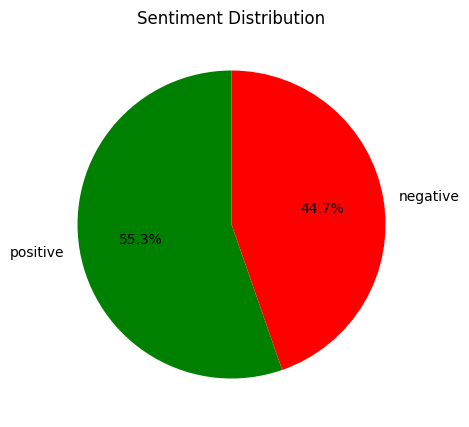

In [4]:
plt.figure(figsize=(5, 5))

# Count sentiments
sentiment_counts = df["sentiment"].value_counts()

# Define colors
colors = []

for label in sentiment_counts.index:
    label_lower = str(label).lower()
    if "positive" in label_lower:
        colors.append("green")
    else:
        colors.append("red")
        
# Pie chart
plt.pie(
    sentiment_counts,
    labels=sentiment_counts.index,
    autopct="%1.1f%%",
    colors=colors,
    startangle=90
)

plt.title("Sentiment Distribution")

plt.show()

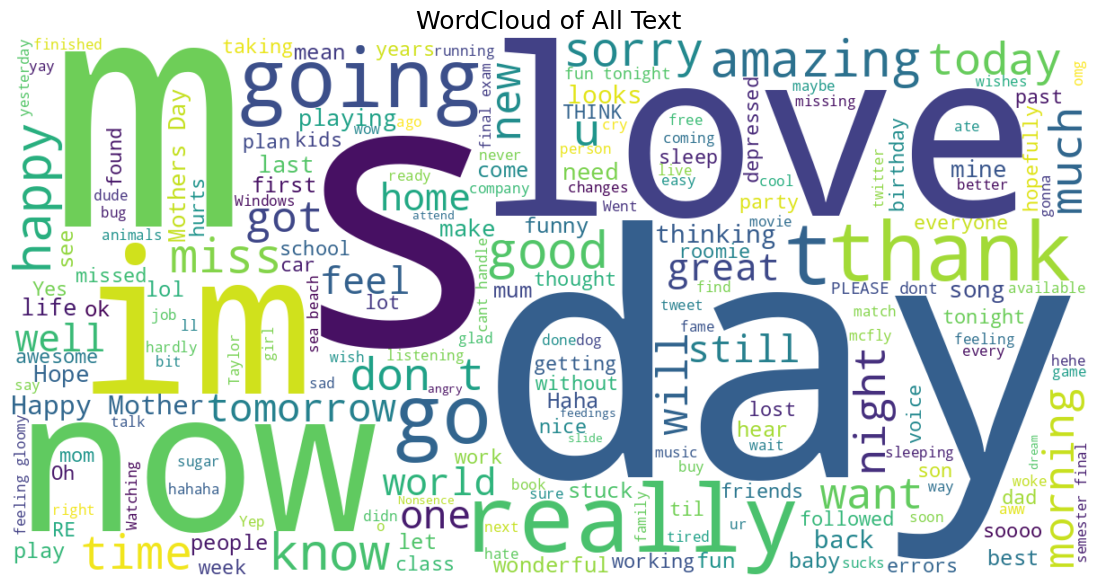

In [5]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Concatenate all text into one string
all_text = " ".join(df["text"].astype(str))

# Generate WordCloud
wordcloud = WordCloud(
    width=1200,
    height=600,
    background_color="white",
    max_words=200
).generate(all_text)

# Plot
plt.figure(figsize=(15, 7))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("WordCloud of All Text", fontsize=18)
plt.show()

In [6]:
df = df[["text", "sentiment"]]
df.rename(columns={"sentiment": "label"}, inplace=True)
df.head()

,text,label
0,What a great day!!! Looks like dream.,positive
1,"I feel sorry, I miss you here in the sea beach",positive
2,Don't angry me,negative
3,We attend in the class just for listening teac...,negative
4,"Those who want to go, let them go",negative


### Text Preprocessing

Text data often contains:

- Uppercase letters
- Punctuation
- Extra spaces
- Stopwords

We usually clean text before training models.

In [7]:
import nltk
nltk.download("stopwords")
from nltk.corpus import stopwords

stop_words = set(stopwords.words("english"))

[nltk_data] Downloading package stopwords to /usr/share/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [8]:
list(stop_words)[:10]

["aren't",
 "they'll",
 'do',
 'when',
 'about',
 'just',
 'that',
 "didn't",
 'is',
 'had']

In [9]:
import string
string.punctuation

'!"#$%&\'()*+,-./:;<=>?@[\\]^_`{|}~'

In [10]:
import re
import string

def preprocess_text(text):
    # Convert to string
    text = str(text)
    
    # -------------------------
    # Lowercasing
    # -------------------------
    text = text.lower()
    
    # -------------------------
    # Remove URLs
    # -------------------------
    text = re.sub(r"http\S+|www\S+|https\S+", "", text)
    
    # -------------------------
    # Remove mentions (@user)
    # -------------------------
    text = re.sub(r"@\w+", "", text)
    
    # -------------------------
    # Remove hashtags symbol
    # Keep the word itself
    # Example: #happy -> happy
    # -------------------------
    text = re.sub(r"#", "", text)
    
    # -------------------------
    # Remove numbers
    # -------------------------
    text = re.sub(r"\d+", "", text)
    
    # -------------------------
    # Remove punctuation
    # -------------------------
    text = text.translate(
        str.maketrans("", "", string.punctuation)
    )
    
    # -------------------------
    # Remove extra spaces
    # -------------------------
    text = re.sub(r"\s+", " ", text).strip()
    
    # -------------------------
    # Tokenization
    # -------------------------
    tokens = text.split()
    
    # -------------------------
    # Remove stopwords
    # -------------------------
    tokens = [
        word for word in tokens
        if word not in stop_words and len(word) > 2
    ]
    
    # -------------------------
    # Join back to sentence
    # -------------------------
    return " ".join(tokens)


df["clean_text"] = df["text"].apply(preprocess_text)

display(df[["text", "clean_text"]].head())

,text,clean_text
0,What a great day!!! Looks like dream.,great day looks like dream
1,"I feel sorry, I miss you here in the sea beach",feel sorry miss sea beach
2,Don't angry me,dont angry
3,We attend in the class just for listening teac...,attend class listening teachers reading slide ...
4,"Those who want to go, let them go",want let


In [11]:
assert df["clean_text"].isna().sum() == 0, "Empty samples Alert!!!"

### Convert Text into Bag of Words Vectors

We use `CountVectorizer` from scikit-learn.

In [12]:
vectorizer = CountVectorizer()

X = vectorizer.fit_transform(df["clean_text"])

In [13]:
# The vectorizer automatically creates a Vocabulary.
# Each word receives an index.
for idx, (key, val) in enumerate(vectorizer.vocabulary_.items()):
    print(f"{key} -> {val}")
    if idx > 3:
        break

great -> 332
day -> 178
looks -> 450
like -> 435
dream -> 216


In [14]:
# Convert Sparse Matrix into DataFrame
bow_df = pd.DataFrame(
    X.toarray(),
    columns=vectorizer.get_feature_names_out()
)

# Now each sentence is represented as numerical features.
bow_df.shape

(300, 881)

In [15]:
bow_df.head()

,accenditenly,accepts,according,account,achievement,act,actress,actually,addicated,address,...,years,yep,yes,yesterday,yet,yor,youre,youtube,zero,â½s
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


### Train-Test Split

We split the dataset into training and testing parts.


In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    df["label"],
    test_size=0.25,
    random_state=42
)

### Train a Machine Learning Model

We will use the Multinomial Naive Bayes algorithm.

Naive Bayes is popular for NLP because:
- It is simple
- It is fast
- It works well on text classification tasks

In [17]:
model = MultinomialNB()

model.fit(X_train, y_train)

MultinomialNB()

In [18]:
y_pred = model.predict(X_test)

print(y_pred)

['negative' 'negative' 'positive' 'negative' 'negative' 'negative'
 'negative' 'negative' 'positive' 'positive' 'negative' 'positive'
 'negative' 'negative' 'negative' 'positive' 'negative' 'positive'
 'positive' 'negative' 'negative' 'positive' 'positive' 'positive'
 'positive' 'negative' 'negative' 'negative' 'positive' 'positive'
 'negative' 'positive' 'negative' 'negative' 'negative' 'negative'
 'positive' 'positive' 'positive' 'positive' 'positive' 'negative'
 'negative' 'positive' 'negative' 'positive' 'negative' 'positive'
 'positive' 'positive' 'negative' 'positive' 'negative' 'negative'
 'positive' 'positive' 'positive' 'positive' 'negative' 'negative'
 'positive' 'negative' 'positive' 'negative' 'positive' 'positive'
 'positive' 'positive' 'negative' 'negative' 'positive' 'negative'
 'negative' 'negative' 'negative']


### Evaluate the Model

In [19]:
accuracy = accuracy_score(y_test, y_pred)

print(f"Accuracy: {accuracy:.2f} | ({len(y_test)})")

Accuracy: 0.75 | (75)


In [20]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

    negative       0.74      0.76      0.75        38
    positive       0.75      0.73      0.74        37

    accuracy                           0.75        75
   macro avg       0.75      0.75      0.75        75
weighted avg       0.75      0.75      0.75        75



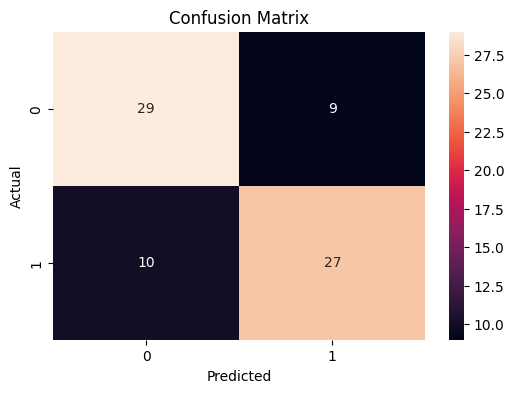

In [21]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 4))

sns.heatmap(cm, annot=True, fmt="d")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

In [22]:
# Predict Custom Sentences

new_sentences = [
    "I love this fantastic film",
    "This was the bad stupid movie"
]

preprocessed_sentences = [
    preprocess_text(sentence) for sentence in new_sentences
]

new_vectors = vectorizer.transform(preprocessed_sentences)

predictions = model.predict(new_vectors)

for text, pred in zip(new_sentences, predictions):
    print(f"Text: {text}")
    print(f"Prediction: {pred}")
    print()

Text: I love this fantastic film
Prediction: positive

Text: This was the bad stupid movie
Prediction: negative



### Understanding Sparse Matrices

Most sentences only contain a few words from the vocabulary.

Example:

| Word     | Count |
| -------- | ----- |
| love     | 1     |
| movie    | 1     |
| amazing  | 0     |
| terrible | 0     |

Because many values are zero, NLP datasets are usually stored as **sparse matrices**.

Sparse matrices save memory and improve efficiency.

---


### Limitations of Bag of Words

Bag of Words is simple, but it has several limitations.

**1. Ignores Word Order**

These sentences have similar vectors:

```python
"dog bites man"
"man bites dog"
```

But their meanings are different.


**2. Ignores Context**

BoW cannot understand semantics.

Example:

```python
"good"
"great"
```

They are similar in meaning, but BoW treats them as completely different words.

**3. Vocabulary Can Become Huge**

Large datasets may contain:

- Millions of unique words
- Typos
- Rare words

This increases memory usage.

---

### Improvements over Bag of Words

More advanced NLP techniques include:

| Method       | Description                         |
| ------------ | ----------------------------------- |
| TF-IDF       | Weights important words higher      |
| Word2Vec     | Learns semantic word embeddings     |
| GloVe        | Dense vector representations        |
| FastText     | Uses subword information            |
| BERT         | Contextual deep learning embeddings |
| Transformers | Modern state-of-the-art NLP models  |


--- 

### Real-World NLP Applications

Bag of Words and text classification are used in:

- Spam detection
- Sentiment analysis
- Fake news detection
- Chatbots
- Email filtering
- Customer feedback analysis
- Document classification

---

### Mini Exercise

Try modifying the pipeline:

1. Add more sentences
2. Create 3 classes instead of 2
3. Try another classifier ML models
4. Use TF-IDF instead of CountVectorizer
5. Remove stopwords

Example:

```python
vectorizer = CountVectorizer(stop_words="english")
```

### Full Pipeline Example

Pipelines simplify machine learning workflows.

In [23]:
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer

pipeline = Pipeline([
    ("vectorizer", TfidfVectorizer()), # CountVectorizer
    ("classifier", MultinomialNB())
])

pipeline.fit(df["text"], df["label"])

prediction = pipeline.predict([
    "I'm very angry"
])

print(prediction)

['negative']


### Final Thoughts

Although modern NLP models such as Transformers and BERT dominate current research and industry applications, understanding Bag of Words remains essential.

It teaches:

- Feature extraction
- Text preprocessing
- Vectorization
- Classical NLP pipelines
- Machine learning for text

Mastering these basics makes advanced NLP much easier to understand.


### Happy Learning!

In [24]:
# Kaz-Roberta | https://huggingface.co/docs/transformers/model_doc/bert | https://huggingface.co/kz-transformers/kaz-roberta-conversational

import torch
from transformers import pipeline

pipe = pipeline(
    task='fill-mask', 
    model='kz-transformers/kaz-roberta-conversational',
    dtype=torch.float16
)
pipe("Мен <mask> саласында жұмыс істеймін, көп ақша табамын.")

config.json:   0%|          | 0.00/636 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/334M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/106 [00:00<?, ?it/s]

RobertaForMaskedLM LOAD REPORT from: kz-transformers/kaz-roberta-conversational
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


vocab.json:   0%|          | 0.00/1.69M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/1.33M [00:00<?, ?B/s]

[{'score': 0.07110595703125,
  'token': 3422,
  'token_str': ' сауда',
  'sequence': 'Мен  сауда саласында жұмыс істеймін, көп ақша табамын.'},
 {'score': 0.0477294921875,
  'token': 19003,
  'token_str': ' IT',
  'sequence': 'Мен  IT саласында жұмыс істеймін, көп ақша табамын.'},
 {'score': 0.04278564453125,
  'token': 2985,
  'token_str': ' қаржы',
  'sequence': 'Мен  қаржы саласында жұмыс істеймін, көп ақша табамын.'},
 {'score': 0.040496826171875,
  'token': 4024,
  'token_str': ' бизнес',
  'sequence': 'Мен  бизнес саласында жұмыс істеймін, көп ақша табамын.'},
 {'score': 0.032806396484375,
  'token': 4065,
  'token_str': ' құрылыс',
  'sequence': 'Мен  құрылыс саласында жұмыс істеймін, көп ақша табамын.'}]